# 房屋销售数据分析

In [1]:
# 导包
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams["font.sans-serif"] = ["SimHei"]  # 指定中文字体


In [3]:
# 加载房屋销售数据
data = pd.read_csv("E:\\250716_大模型\\05_尚硅谷大模型技术之Numpy&Pandas\\2.资料\\data\\house_sales.csv")
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long
0,1,2005-10-24,476315.91,8,4,1921,1856,3,0,0,3,7,1864,87,1979,2010,98001,47.341860,-122.183176
1,2,1937-07-18,698980.64,4,4,1503,6659,2,0,1,1,7,2177,100,1937,0,98010,47.532967,-122.026116
2,3,2008-08-01,663024.75,3,3,3494,3112,2,0,3,4,12,2030,1084,1968,1989,98006,47.345444,-121.635418
3,4,2011-08-31,629698.77,8,1,2618,8264,1,0,2,4,7,1576,1108,1911,1999,98010,47.749573,-121.794627
4,5,2011-02-26,658139.54,1,2,1661,3386,1,0,3,3,2,517,816,1900,0,98001,47.737984,-121.701806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1953-07-11,303685.99,3,2,2378,6259,1,0,4,4,13,2398,450,1927,1992,98010,47.394280,-121.689675
9996,9997,2016-01-03,336882.94,2,1,4837,6226,2,1,2,1,8,2198,1567,1986,2006,98003,47.530260,-122.444554
9997,9998,2021-11-12,423961.29,4,4,4750,1641,2,1,1,2,1,2442,380,2018,0,98004,47.020433,-122.275511
9998,9999,1969-09-03,394782.02,6,5,4108,7847,1,0,4,3,1,4226,1899,1912,0,98001,47.034089,-122.122351


In [21]:
# 数据清晰
# 剔除缺失值
data.dropna(inplace=True)

# IQR异常值检查法
Q1 = data["price"].quantile(0.25)
Q3 = data["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long
0,1,2005-10-24,476315.91,8,4,1921,1856,3,0,0,3,7,1864,87,1979,2010,98001,47.341860,-122.183176
1,2,1937-07-18,698980.64,4,4,1503,6659,2,0,1,1,7,2177,100,1937,0,98010,47.532967,-122.026116
2,3,2008-08-01,663024.75,3,3,3494,3112,2,0,3,4,12,2030,1084,1968,1989,98006,47.345444,-121.635418
3,4,2011-08-31,629698.77,8,1,2618,8264,1,0,2,4,7,1576,1108,1911,1999,98010,47.749573,-121.794627
4,5,2011-02-26,658139.54,1,2,1661,3386,1,0,3,3,2,517,816,1900,0,98001,47.737984,-121.701806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1953-07-11,303685.99,3,2,2378,6259,1,0,4,4,13,2398,450,1927,1992,98010,47.394280,-121.689675
9996,9997,2016-01-03,336882.94,2,1,4837,6226,2,1,2,1,8,2198,1567,1986,2006,98003,47.530260,-122.444554
9997,9998,2021-11-12,423961.29,4,4,4750,1641,2,1,1,2,1,2442,380,2018,0,98004,47.020433,-122.275511
9998,9999,1969-09-03,394782.02,6,5,4108,7847,1,0,4,3,1,4226,1899,1912,0,98001,47.034089,-122.122351


In [24]:
# 日期数据类型转换  string->datatime(TimeStamp)
data["date"] = pd.to_datetime(data["date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9920 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             9920 non-null   int64         
 1   date           9920 non-null   datetime64[ns]
 2   price          9920 non-null   float64       
 3   bedrooms       9920 non-null   int64         
 4   bathrooms      9920 non-null   int64         
 5   sqft_living    9920 non-null   int64         
 6   sqft_lot       9920 non-null   int64         
 7   floors         9920 non-null   int64         
 8   waterfront     9920 non-null   int64         
 9   view           9920 non-null   int64         
 10  condition      9920 non-null   int64         
 11  grade          9920 non-null   int64         
 12  sqft_above     9920 non-null   int64         
 13  sqft_basement  9920 non-null   int64         
 14  yr_built       9920 non-null   int64         
 15  yr_renovated   9920 non-nu

In [27]:
# 创建新的特征
# 房龄
data["age"] = data["date"].dt.year - data["yr_built"]
# 是否翻新
data["is_renovated"] = data["yr_renovated"].apply(lambda x: 1 if x > 0 else 0)
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,age,is_renovated
0,1,2005-10-24,476315.91,8,4,1921,1856,3,0,0,...,7,1864,87,1979,2010,98001,47.341860,-122.183176,26,1
1,2,1937-07-18,698980.64,4,4,1503,6659,2,0,1,...,7,2177,100,1937,0,98010,47.532967,-122.026116,0,0
2,3,2008-08-01,663024.75,3,3,3494,3112,2,0,3,...,12,2030,1084,1968,1989,98006,47.345444,-121.635418,40,1
3,4,2011-08-31,629698.77,8,1,2618,8264,1,0,2,...,7,1576,1108,1911,1999,98010,47.749573,-121.794627,100,1
4,5,2011-02-26,658139.54,1,2,1661,3386,1,0,3,...,2,517,816,1900,0,98001,47.737984,-121.701806,111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1953-07-11,303685.99,3,2,2378,6259,1,0,4,...,13,2398,450,1927,1992,98010,47.394280,-121.689675,26,1
9996,9997,2016-01-03,336882.94,2,1,4837,6226,2,1,2,...,8,2198,1567,1986,2006,98003,47.530260,-122.444554,30,1
9997,9998,2021-11-12,423961.29,4,4,4750,1641,2,1,1,...,1,2442,380,2018,0,98004,47.020433,-122.275511,3,0
9998,9999,1969-09-03,394782.02,6,5,4108,7847,1,0,4,...,1,4226,1899,1912,0,98001,47.034089,-122.122351,57,0


In [37]:

# data.describe(include=[np.number])

# 获取数值型列
numeric_columns = data.select_dtypes(include=[np.number]).columns
# 获取数值型列的描述性统计
data[numeric_columns].describe()


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,age,is_renovated
count,9920.000000,9920.000000,9920.000000,9920.000000,9920.000000,9920.000000,9920.00000,9920.000000,9920.000000,9920.00000,9920.000000,9920.000000,9920.000000,9920.000000,9920.00000,9920.000000,9920.000000,9920.000000,9920.000000,9920.000000
mean,4999.576815,501176.913458,4.497177,3.521976,2906.252621,5520.140827,1.99879,0.498488,2.016230,2.98619,7.020262,2523.120968,999.640423,1962.190323,589.45625,98005.530141,47.400361,-122.095276,30.834073,0.295766
std,2885.515776,96796.446724,2.297992,1.727336,1210.149117,2603.877734,0.81929,0.500023,1.418711,1.41639,3.745790,1153.197332,576.434433,36.072494,909.73899,2.884177,0.231460,0.289922,27.511698,0.456409
min,1.000000,234347.250000,1.000000,1.000000,801.000000,1000.000000,1.00000,0.000000,0.000000,1.00000,1.000000,500.000000,0.000000,1900.000000,0.00000,98001.000000,47.000216,-122.599943,0.000000,0.000000
25%,2502.750000,433569.022500,2.000000,2.000000,1864.750000,3280.750000,1.00000,0.000000,1.000000,2.00000,4.000000,1527.000000,503.000000,1931.000000,0.00000,98003.000000,47.200907,-122.344484,8.000000,0.000000
50%,4998.500000,501590.870000,4.000000,4.000000,2909.000000,5514.000000,2.00000,0.000000,2.000000,3.00000,7.000000,2526.000000,1002.000000,1962.000000,0.00000,98006.000000,47.399660,-122.091732,23.000000,0.000000
75%,7494.250000,567579.977500,7.000000,5.000000,3957.250000,7802.000000,3.00000,1.000000,3.000000,4.00000,10.000000,3538.000000,1502.000000,1993.000000,1962.00000,98008.000000,47.603961,-121.843167,48.000000,1.000000
max,10000.000000,768558.740000,8.000000,6.000000,5000.000000,10000.000000,3.00000,1.000000,4.000000,5.00000,13.000000,4500.000000,2000.000000,2024.000000,2024.00000,98010.000000,47.799975,-121.600304,124.000000,1.000000


In [40]:
# 房价相关性统计
data[numeric_columns].corr()["price"]

id               0.010855
price            1.000000
bedrooms         0.004781
bathrooms        0.007149
sqft_living      0.010877
sqft_lot         0.003869
floors          -0.006972
waterfront       0.002879
view            -0.002639
condition        0.001230
grade            0.005664
sqft_above      -0.004094
sqft_basement   -0.003577
yr_built         0.011795
yr_renovated     0.000071
zipcode          0.009807
lat             -0.001027
long            -0.006395
age             -0.003221
is_renovated     0.000181
Name: price, dtype: float64

In [45]:
# 按邮政编码分组，计算每组的平均房价、平均居住面积、平均卧室数量
# data.groupby("zipcode")[["price","sqft_living","bedrooms"]].mean()
# data.groupby("zipcode").agg({"price": "mean","sqft_living": "mean","bedrooms":"mean"})
data.pivot_table(values=["price","sqft_living","bedrooms"],index="zipcode",aggfunc="mean")


,bedrooms,price,sqft_living
zipcode,,,
98001,4.356657,501692.805588,2915.222546
98002,4.554487,497808.793483,2955.262821
98003,4.551335,497924.782782,2872.228953
98004,4.407950,498747.163954,2857.314854
98005,4.547689,503044.206706,2976.320551
98006,4.600000,505899.199081,2888.367677
98007,4.356436,502986.807941,2900.839604
98008,4.501002,499440.801393,2876.627255
98009,4.472596,500330.593340,2901.382627


In [47]:
# 按是否翻新分组，计算每组的平均房价、平均居住面积、平均卧室数量
data.groupby("is_renovated")[["price","sqft_living","bedrooms"]].mean()

,price,sqft_living,bedrooms
is_renovated,,,
0,501165.589515,2899.757372,4.507157
1,501203.876329,2921.718132,4.473415


In [52]:
# 按房屋使用年限分组（简单分为 5 个区间）
data['age_group']  = pd.cut(data["age"],5)
data.groupby("age_group",observed=True)[["price","sqft_living","bedrooms"]].mean()

,price,sqft_living,bedrooms
age_group,,,
"(-0.124, 24.8]",501491.564379,2912.632708,4.512082
"(24.8, 49.6]",501159.032304,2912.831451,4.487662
"(49.6, 74.4]",501706.543912,2867.487906,4.420180
"(74.4, 99.2]",497096.108718,2910.452450,4.622478
"(99.2, 124.0]",503413.042977,2926.920930,4.358140


In [54]:
# 按年份分组，计算每年的平均房价
data.groupby(data["date"].dt.year)["price"].mean()

date
1900    488884.680000
1902    513972.100000
1903    509519.793333
1905    522640.340000
1906    470978.868333
            ...      
2020    512492.021111
2021    494507.942625
2022    498970.821277
2023    502406.178047
2024    499999.391169
Name: price, Length: 123, dtype: float64

In [57]:
# 按年份和是否翻新分组，计算每年不同翻新情况的平均房价
# data.groupby([data['date'].dt.year, 'is_renovated'])['price'].mean()

data.pivot_table(values="price", index=data['date'].dt.year, columns="is_renovated",aggfunc="mean")


is_renovated,0,1
date,,
1900,488884.680000,NaN
1902,513972.100000,NaN
1903,445335.310000,637888.760000
1905,522640.340000,NaN
1906,470978.868333,NaN
...,...,...
2020,508676.521813,522412.319286
2021,496586.394525,488766.219250
2022,505571.543509,484070.180990


Text(0, 0.5, '频数')

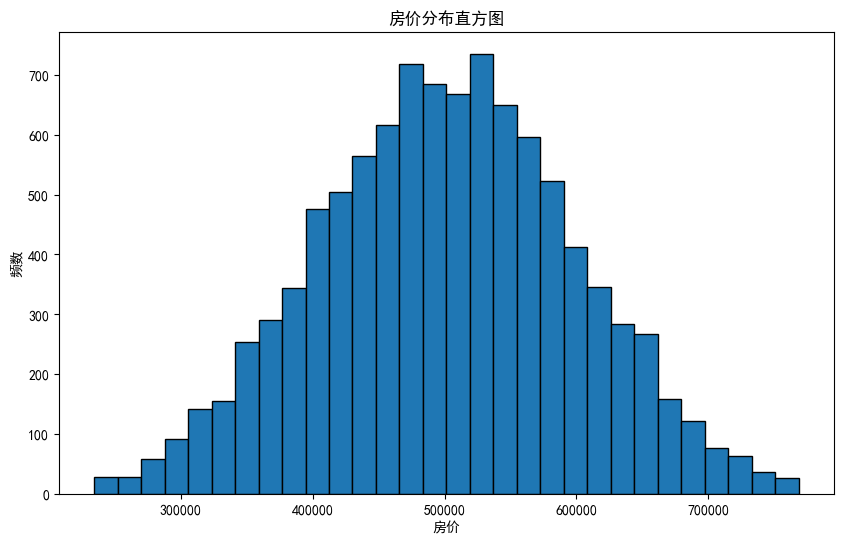

In [61]:
# 可视化
plt.figure(figsize=(10, 6))
plt.hist(data['price'], bins=30, edgecolor='k')
plt.title('房价分布直方图')
plt.xlabel('房价')
plt.ylabel('频数')

Text(0, 0.5, '房价')

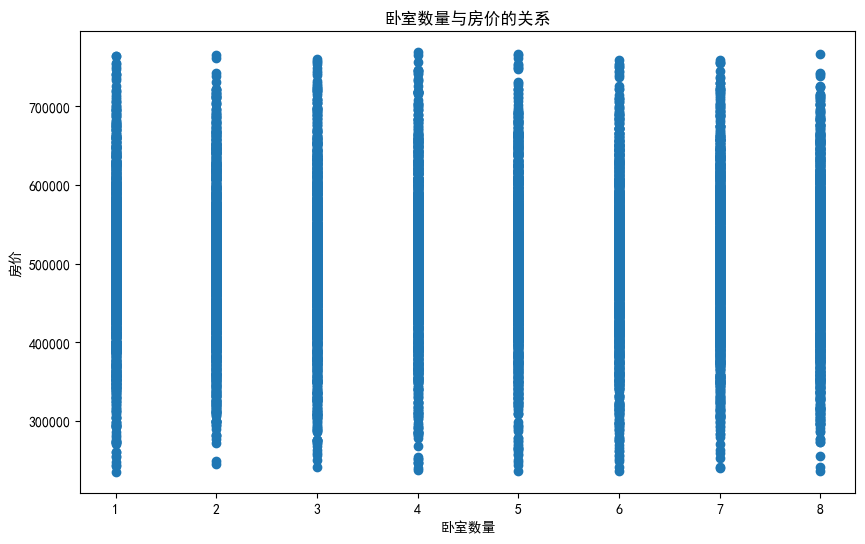

In [62]:
plt.figure(figsize=(10, 6))
plt.scatter(data['bedrooms'], data['price'])
plt.title('卧室数量与房价的关系')
plt.xlabel('卧室数量')
plt.ylabel('房价')
